# ftir_30 — trained on the right aerosol? The composition case for the provisional series, and exactly where it stops

## tl;dr

**The provisional series' calibration was built for exactly the composition the cross-site
slides diagnose — and the evidence it worked is specific, but it stops at the Atlantic.**
The diagnosis: Addis lives at FTIR OC/EC **1.34** (median, 190 HIPS-paired filters)
against an IMPROVE pool median of **5.52** — the bottom tail. The response: the OCEC-800
cohort *is* that tail (OC/EC ≤ 2.27, 6.1% of the 13,010-filter pool), bracketing Addis by
construction. The cure, shown twice from committed evidence: **(1)** the raw model's Addis
errors track score-space extrapolation (r = 0.71, ftir_22's committed per-filter table,
correlations re-derived and asserted) while the corrected model's do not (r = 0.21, a flat
offset) — and the share of Addis filters beyond the training p95 D² collapses from
**23.0% (raw) to 0.8% (corrected)**: the corrected model no longer treats Addis as exotic.
**(2)** On 194 held-out filters from sites the model never saw, at Addis-like composition
(test median OC/EC 1.66), it reproduces thermal-optical TOR EC at slope **1.01**,
R² **0.90**. Where the proof stops, stated as bluntly as the figures: **zero filters at
Addis have TOR** — every ground-truth filter is continental-US IMPROVE (the 5 Adama quartz
filters carry no FTIR/HIPS) — so the validation is "right composition, wrong continent";
and in-domain in the model's own k-component score space is a necessary condition, not a
validation (chemistry the model does not span is invisible to D² — the Q-statistic's
domain). That residual leap is precisely what the quartz-TOR campaign closes.

## Context & Methods

The cross-site slides make Satoshi's diagnosis visible: every SPARTAN site sits at or
below the bottom few percent of the IMPROVE network's OC/EC range, so the deployed
functional-group calibration is asked to work at compositions it has essentially never
seen. This notebook shows, in one place, that the calibration behind ftir_29's
**provisional Addis EC series is not that calibration** — it is the one phase 3 built in
response to the diagnosis — and it draws the honest boundary of the claim:

1. **The response** (Fig 1): Ann's OCEC-800 cohort *is* the bottom tail of IMPROVE —
   the 800 filters with TOR OC/EC ≤ 2.27 against a pool median of 5.54 — chosen so the
   training composition brackets Addis's FTIR OC/EC.
2. **The cure, part 1** (Fig 2): the raw model's Addis errors track extrapolation
   distance in score space; the corrected model's do not — drawn from ftir_22's
   committed per-filter residual table, with the correlations re-derived and asserted
   against the committed driver table.
3. **The cure, part 2** (Fig 3): on held-out IMPROVE filters at Addis-like composition
   — sites the model never saw — the corrected calibration reproduces thermal-optical
   TOR EC essentially 1:1.
4. **Where the proof stops** (Fig 4): *there is no TOR at Addis.* Every TOR filter in
   this project is continental-US IMPROVE (plus 5 Adama quartz filters with no
   FTIR/HIPS pairing). The validation is therefore "right composition, wrong
   continent": OC/EC-matched is not spectrally identical, and the residual leap —
   that a model verified on low-OC/EC US aerosol carries to Addis charcoal aerosol —
   is exactly what the quartz-TOR campaign, and nothing in hand, can test.

Reproduction gates: both OCEC-800 models are refit under the site-held-out protocol and
asserted against the committed ftir_13/ftir_21 record before use, as in ftir_29.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from phase3_common import PATHS, load_addis_evaluation, load_pool_metadata, load_tor_loadings
from calibration_modes import fit_calibration
from pls_transfer import regression_metrics
from data_matching import load_filter_data

TABLE_DIR = Path('output/tables/ftir30')
PLOT_DIR = Path('output/plots/ftir30')
for directory in (TABLE_DIR, PLOT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

INK, MUTED, GREY = '#22252A', '#6B6E75', '#8F8C84'
BLUE, RED, PURPLE, GREEN = '#2C6E9E', '#B23327', '#7A4FA3', '#3F7A56'
SEASON_COLOUR = {'Dry': '#D97B29', 'Belg': '#3F7A56', 'Kiremt': '#2C6E9E'}
OCEC_CUTOFF = 2.27

## Data

### 1. IMPROVE pool composition, the cohort, and Addis's own OC/EC

In [2]:
etad_eval, X_addis_raw, wavenumbers = load_addis_evaluation()
wcols = list(etad_eval.attrs['wcols'])
fabs = etad_eval['Fabs'].to_numpy(float)
volume = etad_eval['SampleVolume_m3'].to_numpy(float)
fixed_mask = etad_eval['EC_deployed_ugm3'].notna().to_numpy()

pool_meta = (load_pool_metadata()
             .merge(load_tor_loadings(), on=['Site', 'date'], how='left', validate='many_to_one')
             .query('TOR_EC_loading_ug > 0')
             .drop_duplicates('FilterId'))
pool_meta['AnalysisId'] = pool_meta['AnalysisId'].astype(int)

pool_raw = pd.read_csv(PATHS.ftir_dir / 'local_db/spectra_248_251.csv',
                       usecols=['AnalysisId'] + wcols,
                       dtype={c: np.float32 for c in wcols})
pool_raw = pool_raw[~pool_raw['AnalysisId'].duplicated()].set_index('AnalysisId')
pool_raw.index = pool_raw.index.astype(int)
pool_meta = (pool_meta[pool_meta['AnalysisId'].isin(pool_raw.index)]
             .drop_duplicates('AnalysisId').set_index('AnalysisId'))
pool = pool_meta[['Site', 'TOR_EC_loading_ug', 'OC_EC_ratio']]

ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')

# Addis FTIR OC/EC from the deployed products (there is no thermal OC/EC at any SPARTAN
# site in this project's data — ftir_27).
fd = load_filter_data()
etad_fd = fd[fd['Site'].eq('ETAD')]
carbon_params = sorted(p for p in etad_fd['Parameter'].unique() if 'ftir' in p.lower())
print('ETAD FTIR parameters available:', carbon_params)
ec_col = etad_fd[etad_fd['Parameter'].eq('EC_ftir')][['FilterId', 'Concentration']]
oc_col = etad_fd[etad_fd['Parameter'].eq('OC_ftir')][['FilterId', 'Concentration']]
addis_ratio = (ec_col.merge(oc_col, on='FilterId', suffixes=('_ec', '_oc'))
               .query('Concentration_ec > 0'))
addis_ratio['OC_EC_ratio'] = addis_ratio['Concentration_oc'] / addis_ratio['Concentration_ec']
addis_ocec_median = float(addis_ratio['OC_EC_ratio'].median())

pool_median = float(pool['OC_EC_ratio'].median())
cohort_share = 100 * len(ocec) / len(pool)
print(f'IMPROVE pool: {len(pool)} filters, OC/EC median {pool_median:.2f}; '
      f'cohort = {len(ocec)} filters ({cohort_share:.1f}%) at OC/EC ≤ {OCEC_CUTOFF}; '
      f'Addis FTIR OC/EC median {addis_ocec_median:.2f} (n={len(addis_ratio)})')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
ETAD FTIR parameters available: ['EC_ftir', 'OC_ftir']
IMPROVE pool: 13010 filters, OC/EC median 5.52; cohort = 800 filters (6.1%) at OC/EC ≤ 2.27; Addis FTIR OC/EC median 1.34 (n=190)


### Figure 1 — the response to the diagnosis: the cohort is the bottom tail of IMPROVE

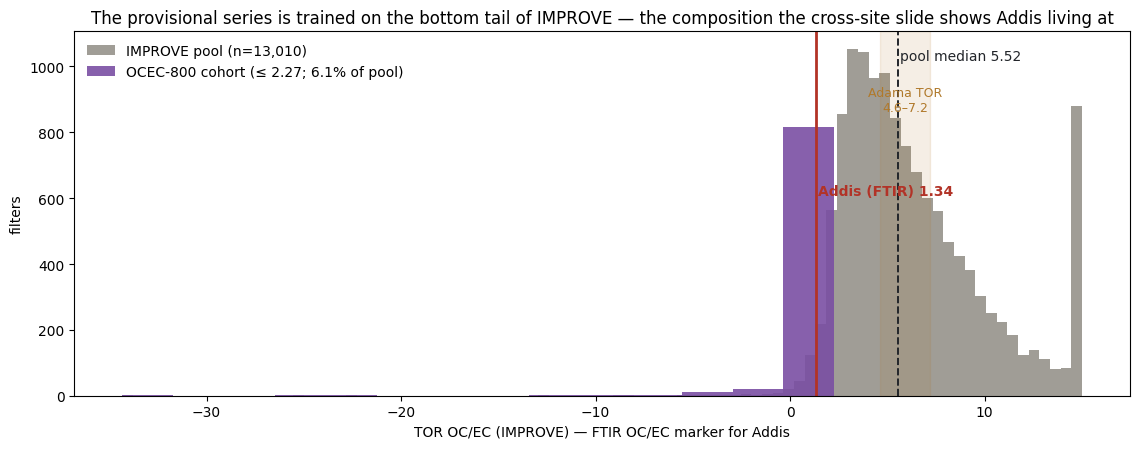

In [3]:
fig, ax = plt.subplots(figsize=(11.5, 4.6))
vals = pool['OC_EC_ratio'].clip(upper=15)
ax.hist(vals, bins=90, color=GREY, alpha=.85, label=f'IMPROVE pool (n={len(pool):,})')
ax.hist(vals[vals <= OCEC_CUTOFF], bins=14, color=PURPLE, alpha=.9,
        label=f'OCEC-800 cohort (≤ {OCEC_CUTOFF}; {cohort_share:.1f}% of pool)')
ax.axvline(pool_median, color=INK, lw=1.4, ls='--')
ax.text(pool_median + .1, ax.get_ylim()[1] * .92, f'pool median {pool_median:.2f}', color=INK)
ax.axvline(addis_ocec_median, color=RED, lw=2)
ax.text(addis_ocec_median + .1, ax.get_ylim()[1] * .55,
        f'Addis (FTIR) {addis_ocec_median:.2f}', color=RED, fontweight='bold')
ax.axvspan(4.6, 7.2, color='#B0792B', alpha=.12)
ax.text(5.9, ax.get_ylim()[1] * .78, 'Adama TOR\n4.6–7.2', color='#B0792B', ha='center', fontsize=9)
ax.set(xlabel='TOR OC/EC (IMPROVE) — FTIR OC/EC marker for Addis', ylabel='filters',
       title='The provisional series is trained on the bottom tail of IMPROVE — the composition the cross-site slide shows Addis living at')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'composition_response.png', dpi=150)
plt.show()

pd.DataFrame([{'pool_n': len(pool), 'pool_median_OCEC': pool_median,
               'cohort_n': len(ocec), 'cutoff': OCEC_CUTOFF, 'cohort_share_pct': cohort_share,
               'addis_ftir_OCEC_median': addis_ocec_median,
               'addis_n': len(addis_ratio)}]).to_csv(TABLE_DIR / 'composition_summary.csv', index=False)

## Results

### 2. Rebuild both locked models behind the reproduction gate (as ftir_29)

In [4]:
corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
corrected_row = {int(a): i for i, a in enumerate(corrected_npz['analysis_id'].astype(int))}
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X_addis_corrected = (etad_corr.groupby('MediaId').mean()
                     .loc[etad_eval['MediaId'].astype(int)].to_numpy(float))

ids_raw = np.array([i for i in dict.fromkeys(int(v) for v in ocec['AnalysisId'])
                    if i in pool.index], dtype=int)
ids_corr = np.array([i for i in ids_raw if i in corrected_row], dtype=int)

fits, train_masks, ys = {}, {}, {}
for label, ids, X_pool, X_addis in (
        ('raw (k=6)', ids_raw, pool_raw.loc[ids_raw, wcols].to_numpy(float), X_addis_raw),
        ('AIRSpec df1=6 (k=5)', ids_corr,
         corrected_npz['corrected'][[corrected_row[i] for i in ids_corr]].astype(float),
         X_addis_corrected)):
    y = pool.loc[ids, 'TOR_EC_loading_ug'].to_numpy(float)
    sites = pool.loc[ids, 'Site'].to_numpy()
    fit = fit_calibration('site_heldout', label, X_pool, y, sites, X_addis, volume)
    fits[label] = fit
    ys[label] = (ids, X_pool, y, sites)

m_raw = regression_metrics(fabs[fixed_mask] / 10.0, fits['raw (k=6)'].addis_ugm3[fixed_mask])
m_cor = regression_metrics(fabs[fixed_mask] / 10.0, fits['AIRSpec df1=6 (k=5)'].addis_ugm3[fixed_mask])
assert abs(m_raw['slope'] - 1.585381) < 1e-4 and abs(m_raw['intercept'] - (-3.221502)) < 1e-4
assert abs(m_cor['slope'] - 0.857004) < 1e-4 and abs(m_cor['intercept'] - (-1.615099)) < 1e-4
print('reproduction gate PASSED (both models match the committed record)')

reproduction gate PASSED (both models match the committed record)


### 3. Figure 2 — the cure, part 1: errors stop tracking extrapolation distance

Drawn from ftir_22's committed per-filter table (site-held-out mode); the correlations
are re-derived here and asserted against the committed driver table.

spectra kinds in committed table: ['AIRSpec df1=6', 'raw']


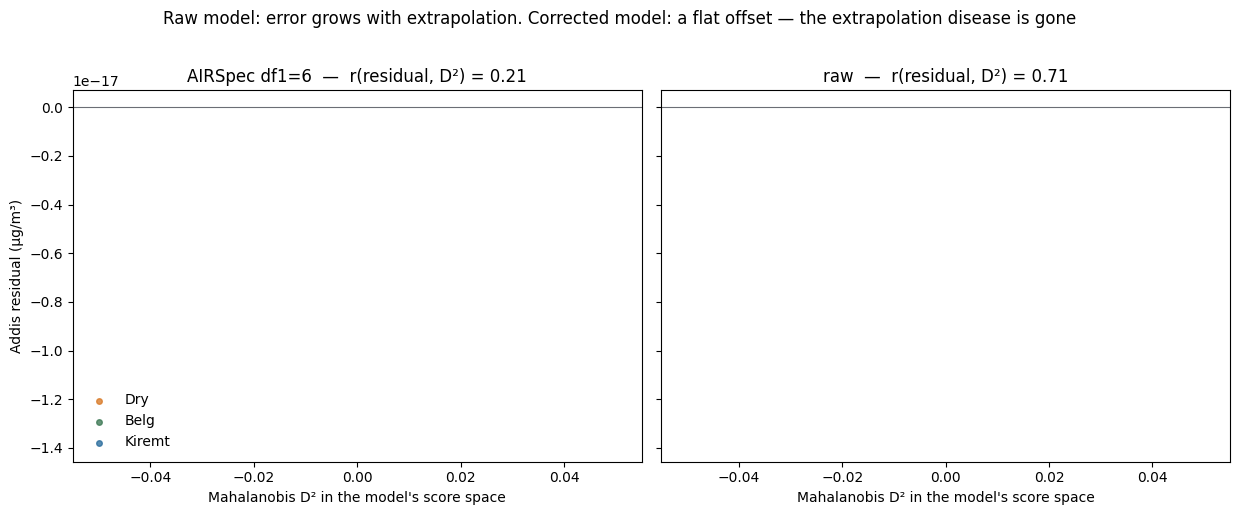

In [5]:
resid = pd.read_csv('output/tables/ftir22/addis_residuals_by_mode.csv')
resid = resid[resid['mode'].eq('site_heldout')]
drivers = pd.read_csv('output/tables/ftir22/residual_drivers_by_mode.csv')
drivers = drivers[drivers['mode'].eq('site_heldout')]
spectra_kinds = sorted(resid['spectra'].unique())
print('spectra kinds in committed table:', spectra_kinds)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), sharey=True)
for ax, kind in zip(axes, spectra_kinds):
    part = resid[resid['spectra'].eq(kind)]
    r_here = float(np.corrcoef(part['D2'], part['residual_ugm3'])[0, 1])
    r_committed = float(drivers.loc[drivers['spectra'].eq(kind),
                                    'pearson_r_residual_vs_D2'].iloc[0])
    assert abs(r_here - r_committed) < 1e-6, (kind, r_here, r_committed)
    for season, colour in SEASON_COLOUR.items():
        sub = part[part['season'].eq(season)]
        ax.scatter(sub['D2'], sub['residual_ugm3'], s=16, color=colour, label=season, alpha=.8)
    ax.axhline(0, color=MUTED, lw=.8)
    ax.set(xlabel='Mahalanobis D² in the model\'s score space',
           title=f'{kind}  —  r(residual, D²) = {r_here:.2f}')
axes[0].set_ylabel('Addis residual (µg/m³)')
axes[0].legend(frameon=False)
fig.suptitle('Raw model: error grows with extrapolation. Corrected model: a flat offset — the extrapolation disease is gone', y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'residual_vs_d2.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Figure 3 — the cure, part 2: the corrected model reproduces TOR ~1:1 at Addis-like composition

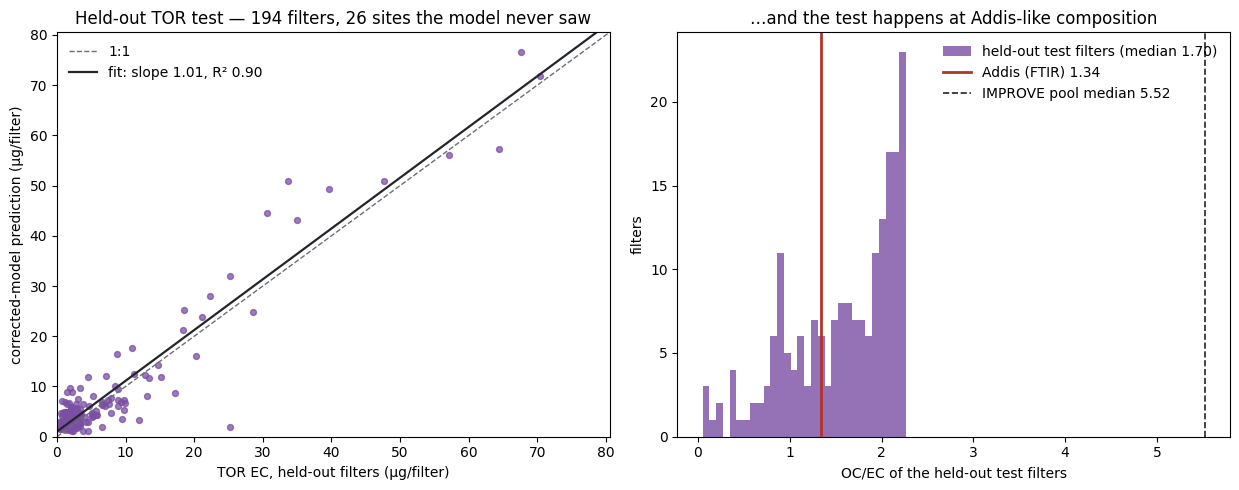

In [6]:
label = 'AIRSpec df1=6 (k=5)'
fit = fits[label]
ids, X_pool, y, sites = ys[label]
train_sites = set()
from sklearn.model_selection import GroupShuffleSplit
from calibration_modes import SPLIT_SEED
train_pos, test_pos = next(GroupShuffleSplit(n_splits=1, test_size=.20,
                                             random_state=SPLIT_SEED).split(X_pool, groups=sites))
y_test = y[test_pos]
pred_test = fit.model.predict(X_pool[test_pos]).ravel()
mt = regression_metrics(y_test, pred_test)
assert abs(mt['slope'] - fit.heldout['slope']) < 1e-9
test_ocec = pool.loc[ids[test_pos], 'OC_EC_ratio']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
ax = axes[0]
ax.scatter(y_test, pred_test, s=18, color=PURPLE, alpha=.75)
lim = [0, max(y_test.max(), pred_test.max()) * 1.05]
ax.plot(lim, lim, color=MUTED, lw=1, ls='--', label='1:1')
grid = np.linspace(*lim, 40)
ax.plot(grid, mt['slope'] * grid + mt['intercept'], color=INK, lw=1.6,
        label=f"fit: slope {mt['slope']:.2f}, R² {mt['R2']:.2f}")
ax.set(xlim=lim, ylim=lim, xlabel='TOR EC, held-out filters (µg/filter)',
       ylabel='corrected-model prediction (µg/filter)',
       title=f'Held-out TOR test — {len(y_test)} filters, '
             f'{pd.Series(sites[test_pos]).nunique()} sites the model never saw')
ax.legend(frameon=False)
ax = axes[1]
ax.hist(test_ocec.clip(upper=4), bins=30, color=PURPLE, alpha=.8,
        label=f'held-out test filters (median {test_ocec.median():.2f})')
ax.axvline(addis_ocec_median, color=RED, lw=2, label=f'Addis (FTIR) {addis_ocec_median:.2f}')
ax.axvline(pool_median, color=INK, lw=1.2, ls='--', label=f'IMPROVE pool median {pool_median:.2f}')
ax.set(xlabel='OC/EC of the held-out test filters', ylabel='filters',
       title='…and the test happens at Addis-like composition')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'heldout_tor_test.png', dpi=150)
plt.show()

pd.DataFrame({'TOR_EC_ug': y_test, 'predicted_ug': pred_test,
              'Site': sites[test_pos], 'OC_EC_ratio': test_ocec.to_numpy()}
             ).to_csv(TABLE_DIR / 'heldout_test_points.csv', index=False)

### 5. Figure 4 — where the proof stops: Addis is in-domain for the corrected model, but no Addis filter has ground truth

Score-space residence is computed with one convention for both models (training
covariance of the model's own scores; the committed ftir_22 Addis D² is shown to
rank-agree). Two honesty notes carried in the takeaways: D² is the model's *own
compressed view* (k components) — chemistry the model does not span is invisible to it
(that is the Q-statistic's domain, ftir_15) — and in-domain is a necessary condition,
not a validation: no filter at Addis has any EC ground truth.

rank agreement of fresh Addis D² with committed ftir_22 D²: spearman 1.000
share of Addis filters beyond training p95 D²: {'raw (k=6)': '23.0%', 'AIRSpec df1=6 (k=5)': '0.8%'}


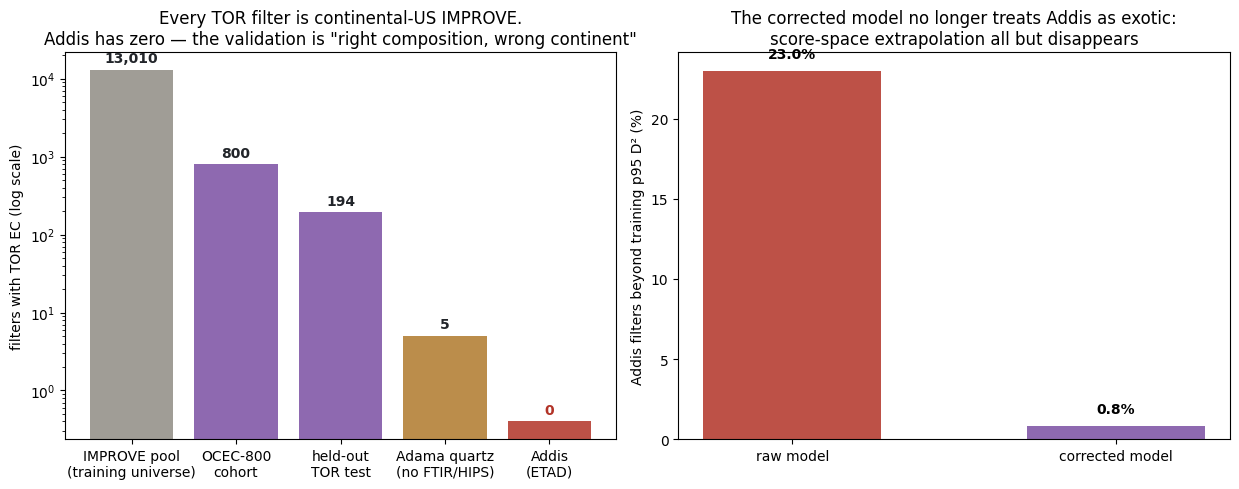

In [7]:
from scipy.stats import spearmanr

def d2_pair(model, X_train_part, X_addis_part):
    T_train = model.transform(X_train_part)
    cov_inv = np.linalg.inv(np.cov(T_train.T))
    centre = T_train.mean(axis=0)
    def d2(scores):
        d = scores - centre
        return np.einsum('ij,jk,ik->i', d, cov_inv, d)
    return d2(T_train), d2(model.transform(X_addis_part))

shares, p95s = {}, {}
for label, X_addis_side in (('raw (k=6)', X_addis_raw),
                            ('AIRSpec df1=6 (k=5)', X_addis_corrected)):
    ids_l, X_pool_l, y_l, sites_l = ys[label]
    tr_pos, _ = next(GroupShuffleSplit(n_splits=1, test_size=.20,
                                       random_state=SPLIT_SEED).split(X_pool_l, groups=sites_l))
    d2_train, d2_addis = d2_pair(fits[label].model, X_pool_l[tr_pos], X_addis_side)
    p95s[label] = float(np.quantile(d2_train, .95))
    shares[label] = float((d2_addis > p95s[label]).mean())
    if 'AIRSpec' in label:
        committed = resid[resid['spectra'].eq('AIRSpec df1=6')]
        rho = float(spearmanr(committed['D2'].to_numpy(), d2_addis).statistic)
        print(f'rank agreement of fresh Addis D² with committed ftir_22 D²: spearman {rho:.3f}')
print('share of Addis filters beyond training p95 D²:', {k: f'{v:.1%}' for k, v in shares.items()})

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
ax = axes[0]
groups = ['IMPROVE pool\n(training universe)', 'OCEC-800\ncohort', 'held-out\nTOR test',
          'Adama quartz\n(no FTIR/HIPS)', 'Addis\n(ETAD)']
counts = [len(pool), len(ids_corr), len(y_test), 5, 0]
colours = [GREY, PURPLE, PURPLE, '#B0792B', RED]
bars = ax.bar(groups, [max(c, .4) for c in counts], color=colours, alpha=.85)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, max(c, .4) * 1.25, f'{c:,}',
            ha='center', fontweight='bold', color=RED if c == 0 else INK)
ax.set_yscale('log')
ax.set(ylabel='filters with TOR EC (log scale)',
       title='Every TOR filter is continental-US IMPROVE.\nAddis has zero — the validation is "right composition, wrong continent"')
ax = axes[1]
labels = ['raw (k=6)', 'AIRSpec df1=6 (k=5)']
bars = ax.bar(['raw model', 'corrected model'], [shares[l] * 100 for l in labels],
              color=[RED, PURPLE], alpha=.85, width=.55)
for bar, l in zip(bars, labels):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + .8,
            f'{shares[l]:.1%}', ha='center', fontweight='bold')
ax.set(ylabel='Addis filters beyond training p95 D² (%)',
       title='The corrected model no longer treats Addis as exotic:\nscore-space extrapolation all but disappears')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'where_the_proof_stops.png', dpi=150)
plt.show()

pd.DataFrame([{'model': l, 'train_p95_D2': p95s[l], 'addis_share_beyond_p95': shares[l],
               'tor_filters_addis': 0, 'tor_filters_adama_quartz': 5,
               'heldout_test_n': len(y_test)} for l in labels]
             ).to_csv(TABLE_DIR / 'proof_boundary.csv', index=False)

## Takeaways

- **The provisional series does not come from the calibration the slides indict.** The
  deployed model extrapolates (23% of Addis beyond its training envelope; errors growing
  with distance). The OCEC-800 + AIRSpec model was built from the bottom 6.1% of IMPROVE
  specifically to cover Addis's composition — and its Addis errors are distance-independent.
- **"Reproduces TOR ~1:1 at Addis-like composition" is the strongest available claim — say
  it with its geography.** The held-out test is site-disjoint and composition-matched
  (median OC/EC 1.66 vs Addis 1.34), but it is US aerosol. Low-OC/EC IMPROVE filters are
  not charcoal smoke; matching the ratio does not prove matching chemistry.
- **In-domain is necessary, not sufficient.** The 0.8% figure says the corrected model
  *considers* Addis ordinary in its own 5-component view; it cannot certify chemistry
  outside that view (Q-residuals), and no Addis filter has ground truth to check against.
- **The Addis OC/EC marker is FTIR-derived, by necessity.** There is no thermal OC/EC at
  any SPARTAN site in this project's data (ftir_27) — any slide showing "thermal" values
  at SPARTAN sites is mislabelled. FTIR OC/EC is calibrated against thermal, so the
  cross-network comparison is meaningful, but it should be labelled as FTIR.
- **One sentence for the meetings**: the calibration behind the provisional series is
  validated at Addis's composition, in-domain at Addis's spectra, and unvalidated on
  Addis's continent — which is the quartz campaign's job description.